In [4]:
def most_hitted_channel(hits, channel):
    # Crea un dizionario per contare i colpi per canale
    channel_counts = {}
    
    for hit_count, ch in zip(hits, channel):
        if hit_count == 1:  # Considera solo eventi con 1 hit
            ch_id = ch[0]  # Prendi il primo canale (assumendo che sia un array)
            if ch_id in channel_counts:
                channel_counts[ch_id] += 1
            else:
                channel_counts[ch_id] = 1
    
    # Trova il canale con il maggior numero di colpi
    most_hit_channel = max(channel_counts, key=channel_counts.get)
    return most_hit_channel, channel_counts[most_hit_channel]

Primi 5 time differences: [-20088.07427355 -20070.26158612 -20094.70299607 -20150.23093392
 -20080.68948789]
Numero totale di eventi con 1 hit: 6975
Canali corrispondenti ai primi 5 eventi: [[93, 46, 46, 71, 8, 82, 89, 85, 86, ..., 68, 79, 86, 90, 83, 73, 0, 0], ...]
Cell0TimeStamp_MCP dei primi 5 eventi: [1.1e+11, 1.7e+11, 2.11e+11, 2.69e+11, 2.83e+11]
cfd_MCP dei primi 5 eventi: [2.56e+03, 2.59e+03, 2.52e+03, 2.51e+03, 2.62e+03]
Cell0TimeStamp_PICOSEC dei primi 5 eventi: [[1.1e+11, 1.09e+11, 1.09e+11, 1.09e+11, ..., 9.47e+10, 9.47e+10, 0, 0], ...]
cfd_PICO dei primi 5 eventi: [[2.44e+03], [2.14e+03], [2.4e+03], [2.33e+03], [2.39e+03]]
Fit results: mu = -20118.822 ps, sigma = 44.480 ps


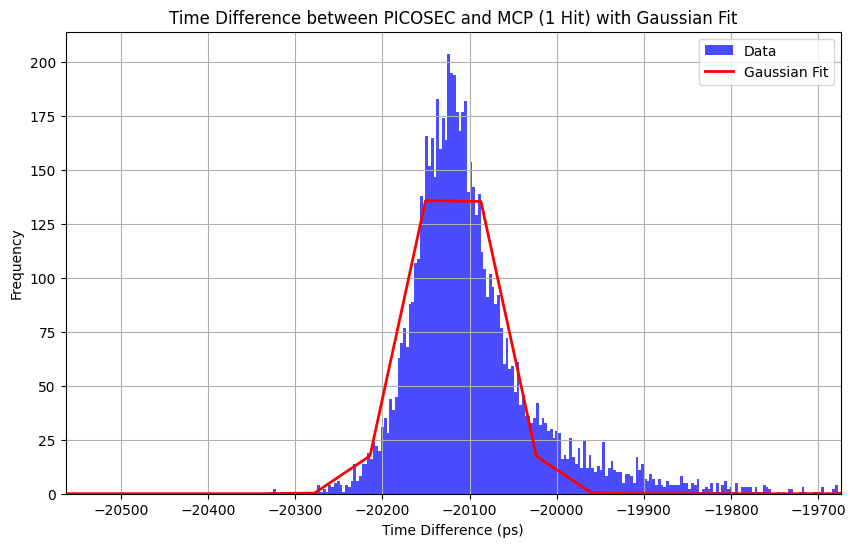

In [1]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Funzione gaussiana
def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Apri il file ROOT
file = uproot.open("/home/riccardo-speziali/after_waveforms_analysis/sampic_mcp_setup_run222_final.root")
tree = file["picoTree"]

# Converti in Awkward Array
data = tree.arrays(library="ak")

# Estrai branch rilevanti
Cell0TimeStamp_PICOSEC = data["Cell0timeSTamp_PICOSEC"]  # array di array
Cell0TimeStamp_MCP    = data["Cell0timestamp_MCP"]       # array piatto
cfd_PICO              = data["pulses_time_cfd30"]       # array di array
cfd_MCP               = data["mcp_time_cfd30"]          # array piatto
hits                  = data["hit_x_event"]             # numero di hit per evento
channel               = data["chanel_PICOSEC"]         # canale PICOSEC
srs                   = data["TriggerIDSRS_MCP"]      # Trigger ID SRS

# Seleziona solo eventi con 1 hit

single_hit_mask = (hits == 1) & (channel[:,0] == 93)  # Se vuoi filtrare anche per canale specifico

# Filtra eventi dove PICOSEC ha almeno 1 valore
valid_mask = ak.num(Cell0TimeStamp_PICOSEC[single_hit_mask]) >= 1

# Prendi il primo (e unico) valore per PICOSEC e MCP
pico_time =  cfd_PICO[single_hit_mask][valid_mask][:,0]
mcp_time  =  cfd_MCP[single_hit_mask][valid_mask]  # già 1D
saved_channel = channel[single_hit_mask][valid_mask]  # Canale corrispondente agli eventi validi
offset = Cell0TimeStamp_MCP[single_hit_mask][valid_mask] * 1e3 - Cell0TimeStamp_PICOSEC[single_hit_mask][valid_mask][:,0] * 1e3
# Calcola la differenza
time_diff = pico_time - mcp_time - offset # (cfd_PICO - cfd_MCP) - (Cell0TimeStamp_MCP - Cell0TimeStamp_PICOSEC), (cfd pico+cell0timestamp pico) - (cfd mcp + cell0timestamp mcp)

# Converte in NumPy e rimuove NaN / inf
time_diff_np = ak.to_numpy(time_diff)
time_diff_np = time_diff_np[np.isfinite(time_diff_np)]

# Controllo: stampiamo i primi valori
print("Primi 5 time differences:", time_diff_np[:5])
print("Numero totale di eventi con 1 hit:", len(time_diff_np))  
print("Canali corrispondenti ai primi 5 eventi:", saved_channel[:2])
print("Cell0TimeStamp_MCP dei primi 5 eventi:", Cell0TimeStamp_MCP[single_hit_mask][valid_mask][:5])
print("cfd_MCP dei primi 5 eventi:", cfd_MCP[single_hit_mask][valid_mask][:5])
print("Cell0TimeStamp_PICOSEC dei primi 5 eventi:", Cell0TimeStamp_PICOSEC[single_hit_mask][valid_mask][:5])
print("cfd_PICO dei primi 5 eventi:", cfd_PICO[single_hit_mask][valid_mask][:5])

# Istogramma
bins = 10000
hist_vals, bin_edges = np.histogram(time_diff_np, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Fit gaussiano

p0 = [max(hist_vals), np.mean(time_diff_np), np.std(time_diff_np)]
params, cov = curve_fit(gauss, bin_centers, hist_vals, p0=p0)
A_fit, mu_fit, sigma_fit = params
print(f"Fit results: mu = {mu_fit:.3f} ps, sigma = {sigma_fit:.3f} ps")

# Plot
plt.figure(figsize=(10,6))
plt.hist(time_diff_np, bins=bins, alpha=0.7, color='blue', label='Data')
x_fit = np.linspace(min(time_diff_np), max(time_diff_np), 500)
plt.plot(x_fit, gauss(x_fit, *params), color='red', linewidth=2, label='Gaussian Fit')
plt.title("Time Difference between PICOSEC and MCP (1 Hit) with Gaussian Fit")
plt.xlabel("Time Difference (ps)")
plt.ylabel("Frequency")
plt.grid()
plt.legend()

# Stringe l'asse x intorno ai dati (ad esempio ±5 sigma attorno a mu_fit)
plt.xlim(mu_fit - 10*sigma_fit, mu_fit + 10*sigma_fit)
plt.show()





Primi 5 time differences: [-20790.6189075  -20558.18492693 -20967.05283714 -20748.99263485
 -20821.02525637]
Numero totale di eventi con 1 hit: 3852
Canali corrispondenti ai primi 5 eventi: [[51, 43, 95, 83, 36, 46, 12, 40, 83, 84, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0], ...]
Cell0TimeStamp_MCP dei primi 5 eventi: [1.17e+10, 8.27e+10, 2.72e+11, 4.14e+11, 6.31e+11]
cfd_MCP dei primi 5 eventi: [2.67e+03, 2.65e+03, 2.66e+03, 2.56e+03, 2.36e+03]
Cell0TimeStamp_PICOSEC dei primi 5 eventi: [[1.17e+10, 1.17e+10, 1.16e+10, 1.11e+10, 1.08e+10, ..., 0, 0, 0, 0, 0], ...]
cfd_PICO dei primi 5 eventi: [[1.85e+03], [1.59e+03], [2.49e+03], [2.38e+03], [2.21e+03]]
Fit results: mu = -20921.286 ps, sigma = 50.303 ps


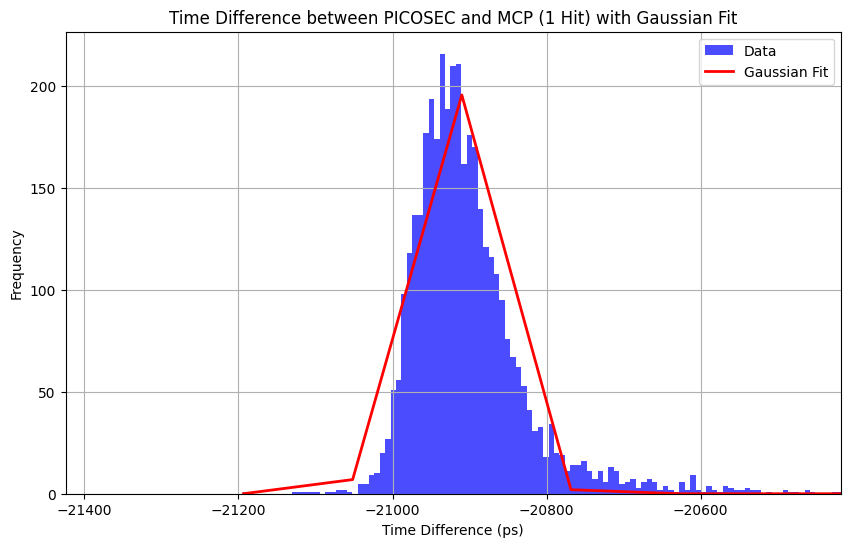

Primi 5 time differences: [-20678.38984464 -20734.91855272 -20596.51198123 -20665.53784769
 -20666.11780528]
Numero totale di eventi con 1 hit: 2923
Canali corrispondenti ai primi 5 eventi: [[50, 48, 53, 41, 43, 45, 42, 14, 6, 85, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0], ...]
Cell0TimeStamp_MCP dei primi 5 eventi: [8.68e+09, 1.02e+10, 1.55e+11, 1.86e+11, 2.57e+11]
cfd_MCP dei primi 5 eventi: [2.56e+03, 2.55e+03, 2.36e+03, 2.51e+03, 2.51e+03]
Cell0TimeStamp_PICOSEC dei primi 5 eventi: [[8.68e+09, 8.65e+09, 8.64e+09, 8.64e+09, 8.64e+09, ..., 0, 0, 0, 0, 0], ...]
cfd_PICO dei primi 5 eventi: [[2.09e+03], [2.25e+03], [2.09e+03], [1.94e+03], [2.28e+03]]
Fit results: mu = -20709.150 ps, sigma = -49.359 ps


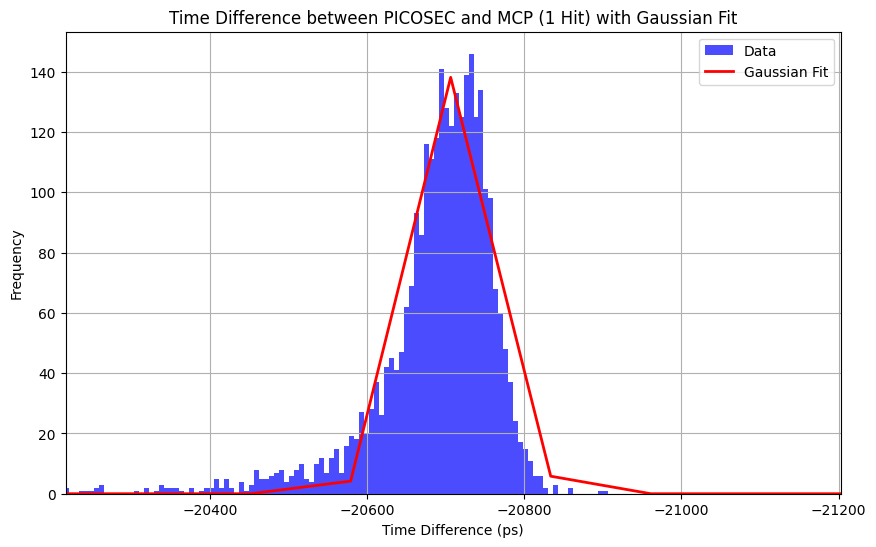

Primi 5 time differences: [-20562.68555874 -20463.86468451 -20454.77786507 -20529.14821682
 -20516.28261478]
Numero totale di eventi con 1 hit: 3790
Canali corrispondenti ai primi 5 eventi: [[49, 46, 83, 83, 36, 46, 12, 40, 83, 84, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0], ...]
Cell0TimeStamp_MCP dei primi 5 eventi: [1.14e+10, 2.43e+10, 3.93e+10, 4.01e+10, 5.36e+10]
cfd_MCP dei primi 5 eventi: [2.64e+03, 2.7e+03, 2.6e+03, 2.53e+03, 2.48e+03]
Cell0TimeStamp_PICOSEC dei primi 5 eventi: [[1.14e+10, 1.14e+10, 1.14e+10, 1.11e+10, 1.08e+10, ..., 0, 0, 0, 0, 0], ...]
cfd_PICO dei primi 5 eventi: [[2.4e+03], [1.15e+03], [2.35e+03], [2.44e+03], [2.06e+03]]
Fit results: mu = -20522.692 ps, sigma = 49.756 ps


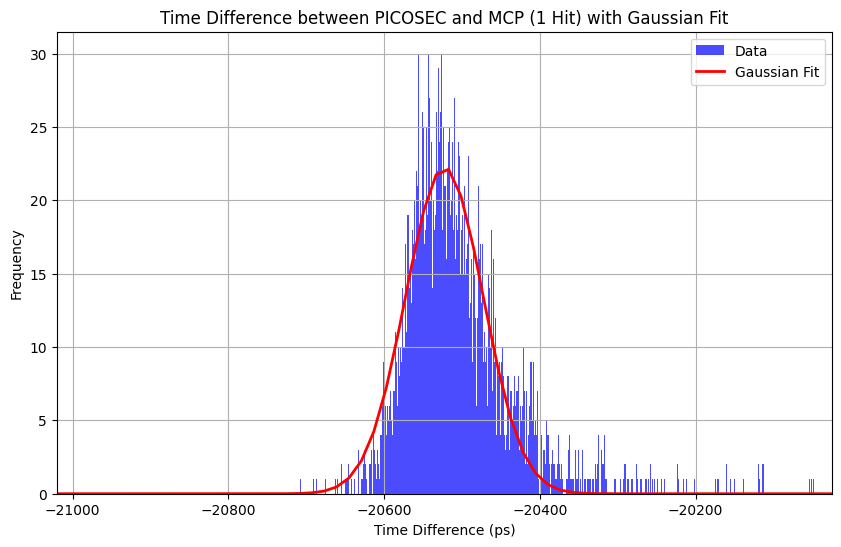

In [6]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Funzione gaussiana
def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Apri il file ROOT
file = uproot.open("/home/riccardo-speziali/after_waveforms_analysis/sampic_mcp_setup_run222_final.root")
tree = file["picoTree"]

# Converti in Awkward Array
data = tree.arrays(library="ak")

# Estrai branch rilevanti
Cell0TimeStamp_PICOSEC = data["Cell0timeSTamp_PICOSEC"]  # array di array
Cell0TimeStamp_MCP    = data["Cell0timestamp_MCP"]       # array piatto
cfd_PICO              = data["pulses_time_cfd30"]       # array di array
cfd_MCP               = data["mcp_time_cfd30"]          # array piatto
hits                  = data["hit_x_event"]             # numero di hit per evento
channel               = data["chanel_PICOSEC"]         # canale PICOSEC
srs                   = data["TriggerIDSRS_MCP"]      # Trigger ID SRS

# Seleziona solo eventi con 1 hit
for i in range(51, 48, -1):  # Prova canali dal 51 al 46
    single_hit_mask = (hits == 1) & (channel[:,0] == i)  # Se vuoi filtrare anche per canale specifico

    # Filtra eventi dove PICOSEC ha almeno 1 valore
    valid_mask = ak.num(Cell0TimeStamp_PICOSEC[single_hit_mask]) >= 1

    # Prendi il primo (e unico) valore per PICOSEC e MCP
    pico_time =  cfd_PICO[single_hit_mask][valid_mask][:,0]
    mcp_time  =  cfd_MCP[single_hit_mask][valid_mask]  # già 1D
    saved_channel = channel[single_hit_mask][valid_mask]  # Canale corrispondente agli eventi validi
    offset = Cell0TimeStamp_MCP[single_hit_mask][valid_mask] * 1e3 - Cell0TimeStamp_PICOSEC[single_hit_mask][valid_mask][:,0] * 1e3
    # Calcola la differenza
    time_diff = pico_time - mcp_time - offset

    # Converte in NumPy e rimuove NaN / inf
    time_diff_np = ak.to_numpy(time_diff)
    time_diff_np = time_diff_np[np.isfinite(time_diff_np)]

    # Controllo: stampiamo i primi valori
    print("Primi 5 time differences:", time_diff_np[:5])
    print("Numero totale di eventi con 1 hit:", len(time_diff_np))  
    print("Canali corrispondenti ai primi 5 eventi:", saved_channel[:2])
    print("Cell0TimeStamp_MCP dei primi 5 eventi:", Cell0TimeStamp_MCP[single_hit_mask][valid_mask][:5])
    print("cfd_MCP dei primi 5 eventi:", cfd_MCP[single_hit_mask][valid_mask][:5])
    print("Cell0TimeStamp_PICOSEC dei primi 5 eventi:", Cell0TimeStamp_PICOSEC[single_hit_mask][valid_mask][:5])
    print("cfd_PICO dei primi 5 eventi:", cfd_PICO[single_hit_mask][valid_mask][:5])

    # Istogramma
    
    bins = 10000
    
    hist_vals, bin_edges = np.histogram(time_diff_np, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Fit gaussiano

    p0 = [max(hist_vals), np.mean(time_diff_np), np.std(time_diff_np)]
    params, cov = curve_fit(gauss, bin_centers, hist_vals, p0=p0)
    A_fit, mu_fit, sigma_fit = params
    print(f"Fit results: mu = {mu_fit:.3f} ps, sigma = {sigma_fit:.3f} ps")

    # Plot
    plt.figure(figsize=(10,6))
    plt.hist(time_diff_np, bins=bins, alpha=0.7, color='blue', label='Data')
    x_fit = np.linspace(min(time_diff_np), max(time_diff_np), 500)
    plt.plot(x_fit, gauss(x_fit, *params), color='red', linewidth=2, label='Gaussian Fit')
    plt.title("Time Difference between PICOSEC and MCP (1 Hit) with Gaussian Fit")
    plt.xlabel("Time Difference (ps)")
    plt.ylabel("Frequency")
    plt.grid()
    plt.legend()

    # Stringe l'asse x intorno ai dati (ad esempio ±5 sigma attorno a mu_fit)
    plt.xlim(mu_fit - 10*sigma_fit, mu_fit + 10*sigma_fit)
    plt.show()



